In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
# univariate statistics
max_steps = 100000
step_size = 1000

ts = [x * step_size for x in range(1, int(max_steps/step_size) + 1)]

In [3]:
def ks_test_plot(data1, data2,name1,name2,metric):
    ks_stat, p_value = stats.ks_2samp(data1, data2)

    # 3. Print the results beautifully
    print("--- KS Test Results ---")
    print(f"KS Statistic (D) : {ks_stat:.4f}")
    print(f"P-value          : {p_value:.4e}")
    # Interpret based on a standard 0.05 alpha level
    alpha = 0.05
    if p_value < alpha:
        print("Result           : Reject null hypothesis (Distributions are significantly different)")
    else:
        print("Result           : Fail to reject null hypothesis (Distributions are identical)")

    # 4. Plot the eCDFs
    plt.figure(figsize=(10, 6))

    # Plot the cumulative distributions
    plt.hist(data1, bins=200, density=True, histtype='step', 
            cumulative=True, label=f'{name1} (eCDF)', color='blue', linewidth=2)
    plt.hist(data2, bins=200, density=True, histtype='step', 
            cumulative=True, label=f'{name2} (eCDF)', color='red', linewidth=2)

    # Visually highlight the KS statistic (maximum distance)
    # Find the range to evaluate the vertical line
    min_val = min(np.min(data1), np.min(data2))
    max_val = max(np.max(data1), np.max(data2))
    values = np.linspace(min_val, max_val, 1000)

    cdf1 = np.searchsorted(np.sort(data1), values, side='right') / len(data1)
    cdf2 = np.searchsorted(np.sort(data2), values, side='right') / len(data2)

    d_index = np.argmax(np.abs(cdf1 - cdf2))
    plt.vlines(values[d_index], cdf1[d_index], cdf2[d_index], 
            color='green', linestyle='--', linewidth=2, 
            label=f'KS Statistic (Max Distance = {ks_stat:.4f})')

    plt.title(f'KS Test: Empirical Cumulative Distribution Functions (eCDF) of {metric}')
    plt.xlabel('Values')
    plt.ylabel('Cumulative Probability')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

def ks_df(seeds):
    ks = [[] for i in seeds]
    temp = 0

    for i in range(len(seeds)):
        print(f"Upper: {i}")
        for temp in range(len(seeds)):
            data1 = seeds[i]
            data2 = seeds[temp]

            ks_stat, p_value = stats.ks_2samp(data1, data2)
            ks[i].append(ks_stat)

    ks = pd.DataFrame(ks,columns=range(len(seeds)))
        
    return ks


In [4]:
con_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/DemPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        con_dempercs.append(tempvotes[s,:])

con_dempercs = np.array(con_dempercs)

medianprops = dict(color='black')

c_con="tab:blue"

In [5]:
seed1_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/DemPercs_1_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed1_dempercs.append(tempvotes[s,:])

seed1_dempercs = np.array(seed1_dempercs)

medianprops = dict(color='black')

c_1="tab:green"

In [6]:
seed2_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/DemPercs_2_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed2_dempercs.append(tempvotes[s,:])

seed2_dempercs = np.array(seed2_dempercs)

medianprops = dict(color='black')

c_2="tab:orange"

In [7]:
seed3_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/DemPercs_3_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed3_dempercs.append(tempvotes[s,:])

seed3_dempercs = np.array(seed3_dempercs)

medianprops = dict(color='black')

c_3="tab:red"

In [8]:
seed4_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/DemPercs_4_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed4_dempercs.append(tempvotes[s,:])

seed4_dempercs = np.array(seed4_dempercs)

medianprops = dict(color='black')

c_4="tab:brown"

In [9]:
seed5_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/DemPercs_5_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed5_dempercs.append(tempvotes[s,:])

seed5_dempercs = np.array(seed5_dempercs)

medianprops = dict(color='black')

c_5="tab:cyan"

In [10]:
alarm_dempercs = []

tempvotes=np.loadtxt(f"./Redist Analysis/GA_ALARM_Ensemble_Stats/DemPercs.csv", delimiter=",")
for s in range(5000):
    alarm_dempercs.append(tempvotes[s,:])

alarm_dempercs = np.array(alarm_dempercs)

medianprops = dict(color='black')

c_al="tab:purple"

In [39]:
for list in con_dempercs:
    list.sort()

for list in seed1_dempercs:
    list.sort()

for list in seed2_dempercs:
    list.sort()

for list in seed3_dempercs:
    list.sort()

for list in seed4_dempercs:
    list.sort()

for list in seed5_dempercs:
    list.sort()

for list in alarm_dempercs:
    list.sort()

In [40]:
d_percs = [con_dempercs, seed1_dempercs, seed2_dempercs, seed3_dempercs, seed4_dempercs, seed5_dempercs]

for d in d_percs:
    d = np.array(d)

In [42]:
final_ks_dem = []
for dist in range(14):
    dist_percents = []
    for i in range(len(d_percs)):
        for j in range(i, len(d_percs)):
            dist_percents.append(stats.ks_2samp(d_percs[i][:, dist], d_percs[j][:, dist])[0])

    final_ks_dem.append(sum(dist_percents)/len(dist_percents))

In [45]:
final_ks_dem = pd.DataFrame(final_ks_dem)

final_ks_dem

,0
0,0.043271
1,0.035357
2,0.025287
3,0.028293
4,0.035655
5,0.035013
6,0.034261
7,0.029004
8,0.025853
9,0.038091


Text(0.5, 1.0, 'GA Districts % Democratic')

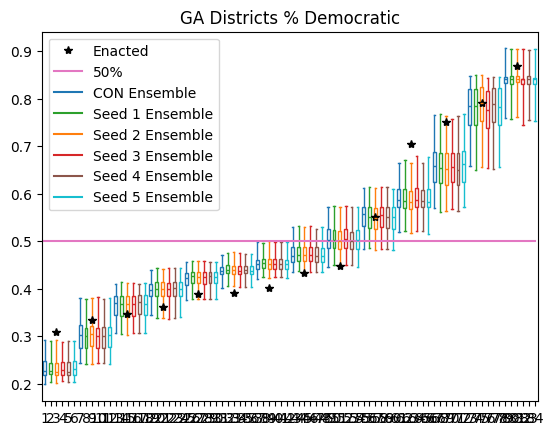

In [12]:
plt.boxplot(
    con_dempercs,
    positions=[1, 7, 13, 19, 25, 31, 37, 43, 49, 55, 61, 67, 73, 79],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_con),
    capprops=dict(color=c_con),
    whiskerprops=dict(color=c_con),
    flierprops=dict(color=c_con,markeredgecolor=c_con),
    medianprops=dict(color=c_con)
)

plt.boxplot(
    seed1_dempercs,
    positions=[2, 8, 14, 20, 26, 32, 38, 44, 50, 56, 62, 68, 74, 80],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_1),
    capprops=dict(color=c_1),
    whiskerprops=dict(color=c_1),
    flierprops=dict(color=c_1,markeredgecolor=c_1),
    medianprops=dict(color=c_1)
)

plt.boxplot(
    seed2_dempercs,
    positions=[3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_2),
    capprops=dict(color=c_2),
    whiskerprops=dict(color=c_2),
    flierprops=dict(color=c_2,markeredgecolor=c_2),
    medianprops=dict(color=c_2)
)

plt.boxplot(
    seed3_dempercs,
    positions=[4, 10, 16, 22, 28, 34, 40, 46, 52, 58, 64, 70, 76, 82],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_3),
    capprops=dict(color=c_3),
    whiskerprops=dict(color=c_3),
    flierprops=dict(color=c_3,markeredgecolor=c_3),
    medianprops=dict(color=c_3)
)

plt.boxplot(
    seed4_dempercs,
    positions=[5, 11, 17, 23, 29, 35, 41, 47, 53, 59, 65, 71, 77, 83],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_4),
    capprops=dict(color=c_4),
    whiskerprops=dict(color=c_4),
    flierprops=dict(color=c_4,markeredgecolor=c_4),
    medianprops=dict(color=c_4)
)

plt.boxplot(
    seed5_dempercs,
    positions=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)

plt.plot([3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],
         [0.3096843317358888,
 0.33400121506757763,
 0.3475417097169912,
 0.36115157970306067,
 0.38956362378657466,
 0.3918099647872283,
 0.40251653995299314,
 0.43215007987143433,
 0.4487048236247402,
 0.5520492403298138,
 0.7047566329296624,
 0.7503875022749172,
 0.7915081752160049,
 0.86851601496066], "*",color="k",label="Enacted")

plt.plot([0.5,84],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:blue',label='CON Ensemble')
plt.plot([],[],color='tab:green',label='Seed 1 Ensemble')
plt.plot([],[],color='tab:orange',label='Seed 2 Ensemble')
plt.plot([],[],color='tab:red',label='Seed 3 Ensemble')
plt.plot([],[],color='tab:brown',label='Seed 4 Ensemble')
plt.plot([],[],color='tab:cyan',label='Seed 5 Ensemble')
plt.legend()
plt.title("GA Districts % Democratic")

Text(0.5, 1.0, 'GA Districts % Democratic')

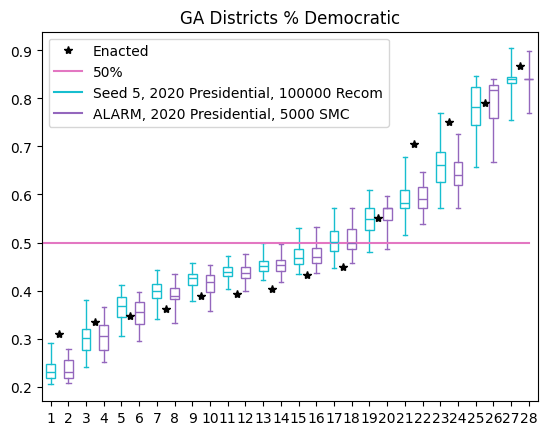

In [26]:
plt.boxplot(
    seed5_dempercs,
    positions=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)

plt.boxplot(
    alarm_dempercs,
    positions=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_al),
    capprops=dict(color=c_al),
    whiskerprops=dict(color=c_al),
    flierprops=dict(color=c_al,markeredgecolor=c_al),
    medianprops=dict(color=c_al)
)

plt.plot([1.5, 3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5],
         [0.3096843317358888,
 0.33400121506757763,
 0.3475417097169912,
 0.36115157970306067,
 0.38956362378657466,
 0.3918099647872283,
 0.40251653995299314,
 0.43215007987143433,
 0.4487048236247402,
 0.5520492403298138,
 0.7047566329296624,
 0.7503875022749172,
 0.7915081752160049,
 0.86851601496066], "*",color="k",label="Enacted")

plt.plot([0.5,28],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:cyan',label='Seed 5, 2020 Presidential, 100000 Recom')
plt.plot([],[],color='tab:purple',label='ALARM, 2020 Presidential, 5000 SMC')
plt.legend()
plt.title("GA Districts % Democratic")

Text(0.5, 1.0, 'GA Districts % Black')

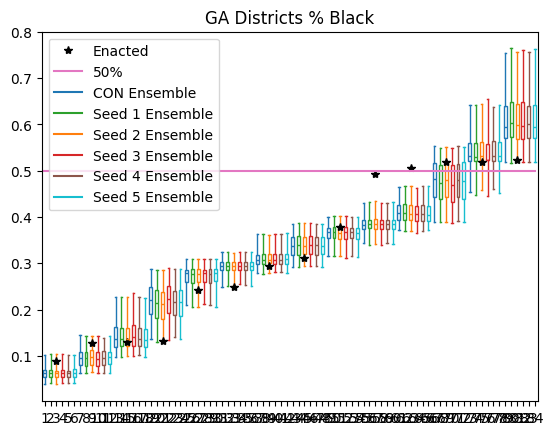

In [21]:
con_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/BlackPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        con_blackpercs.append(tempvotes[s,:])

con_blackpercs = np.array(con_blackpercs)

medianprops = dict(color='black')

c_con="tab:blue"

seed1_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/BlackPercs_1_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed1_blackpercs.append(tempvotes[s,:])

seed1_blackpercs = np.array(seed1_blackpercs)

medianprops = dict(color='black')

c_1="tab:green"

seed2_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/BlackPercs_2_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed2_blackpercs.append(tempvotes[s,:])

seed2_blackpercs = np.array(seed2_blackpercs)

medianprops = dict(color='black')

c_2="tab:orange"

seed3_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/BlackPercs_3_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed3_blackpercs.append(tempvotes[s,:])

seed3_blackpercs = np.array(seed3_blackpercs)

medianprops = dict(color='black')

c_3="tab:red"

seed4_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/BlackPercs_4_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed4_blackpercs.append(tempvotes[s,:])

seed4_blackpercs = np.array(seed4_blackpercs)

medianprops = dict(color='black')

c_4="tab:brown"

seed5_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./GA_Ensemble_Stats/BlackPercs_5_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed5_blackpercs.append(tempvotes[s,:])

seed5_blackpercs = np.array(seed5_blackpercs)

medianprops = dict(color='black')

c_5="tab:cyan"

alarm_blackpercs = []

tempvotes=np.loadtxt(f"./Redist Analysis/GA_ALARM_Ensemble_Stats/BlackPerc.csv", delimiter=",")
for s in range(5000):
    alarm_blackpercs.append(tempvotes[s,:])

alarm_blackpercs = np.array(alarm_blackpercs)

medianprops = dict(color='black')

c_al="tab:purple"


plt.boxplot(
    con_blackpercs,
    positions=[1, 7, 13, 19, 25, 31, 37, 43, 49, 55, 61, 67, 73, 79],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_con),
    capprops=dict(color=c_con),
    whiskerprops=dict(color=c_con),
    flierprops=dict(color=c_con,markeredgecolor=c_con),
    medianprops=dict(color=c_con)
)

plt.boxplot(
    seed1_blackpercs,
    positions=[2, 8, 14, 20, 26, 32, 38, 44, 50, 56, 62, 68, 74, 80],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_1),
    capprops=dict(color=c_1),
    whiskerprops=dict(color=c_1),
    flierprops=dict(color=c_1,markeredgecolor=c_1),
    medianprops=dict(color=c_1)
)

plt.boxplot(
    seed2_blackpercs,
    positions=[3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_2),
    capprops=dict(color=c_2),
    whiskerprops=dict(color=c_2),
    flierprops=dict(color=c_2,markeredgecolor=c_2),
    medianprops=dict(color=c_2)
)

plt.boxplot(
    seed3_blackpercs,
    positions=[4, 10, 16, 22, 28, 34, 40, 46, 52, 58, 64, 70, 76, 82],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_3),
    capprops=dict(color=c_3),
    whiskerprops=dict(color=c_3),
    flierprops=dict(color=c_3,markeredgecolor=c_3),
    medianprops=dict(color=c_3)
)

plt.boxplot(
    seed4_blackpercs,
    positions=[5, 11, 17, 23, 29, 35, 41, 47, 53, 59, 65, 71, 77, 83],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_4),
    capprops=dict(color=c_4),
    whiskerprops=dict(color=c_4),
    flierprops=dict(color=c_4,markeredgecolor=c_4),
    medianprops=dict(color=c_4)
)

plt.boxplot(
    seed5_blackpercs,
    positions=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)


plt.plot([3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],[0.08876158793582248,
 0.12824427682558467,
 0.13056492433308983,
 0.1325798276868282,
 0.2420699332921427,
 0.24894472977393303,
 0.29365592704531707,
 0.3115617493343338,
 0.3787744651247334,
 0.49291171372528175,
 0.5062111598303611,
 0.5178326600003657,
 0.5198877071267722,
 0.5236616185213019],"*",color="k",label="Enacted")

plt.plot([0.5,84],[0.5,0.5],color="tab:pink",label="50%")

plt.plot([],[],color='tab:blue',label='CON Ensemble')
plt.plot([],[],color='tab:green',label='Seed 1 Ensemble')
plt.plot([],[],color='tab:orange',label='Seed 2 Ensemble')
plt.plot([],[],color='tab:red',label='Seed 3 Ensemble')
plt.plot([],[],color='tab:brown',label='Seed 4 Ensemble')
plt.plot([],[],color='tab:cyan',label='Seed 5 Ensemble')
plt.legend()
plt.title("GA Districts % Black")

Text(0.5, 1.0, 'GA Districts % Black')

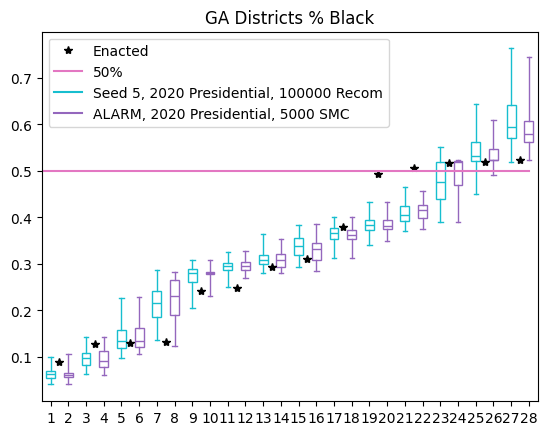

In [4]:
plt.boxplot(
    seed5_blackpercs,
    positions=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)

plt.boxplot(
    alarm_blackpercs,
    positions=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_al),
    capprops=dict(color=c_al),
    whiskerprops=dict(color=c_al),
    flierprops=dict(color=c_al,markeredgecolor=c_al),
    medianprops=dict(color=c_al)
)

plt.plot([1.5, 3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5],
         [0.08876158793582248,
 0.12824427682558467,
 0.13056492433308983,
 0.1325798276868282,
 0.2420699332921427,
 0.24894472977393303,
 0.29365592704531707,
 0.3115617493343338,
 0.3787744651247334,
 0.49291171372528175,
 0.5062111598303611,
 0.5178326600003657,
 0.5198877071267722,
 0.5236616185213019], "*",color="k",label="Enacted")

plt.plot([0.5,28],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:cyan',label='Seed 5, 2020 Presidential, 100000 Recom')
plt.plot([],[],color='tab:purple',label='ALARM, 2020 Presidential, 5000 SMC')
plt.legend()
plt.title("GA Districts % Black")

In [22]:
for list in con_blackpercs:
    list.sort()

for list in seed1_blackpercs:
    list.sort()

for list in seed2_blackpercs:
    list.sort()

for list in seed3_blackpercs:
    list.sort()

for list in seed4_blackpercs:
    list.sort()

for list in seed5_blackpercs:
    list.sort()

for list in alarm_blackpercs:
    list.sort()

In [24]:
b_percs = [con_blackpercs, seed1_blackpercs, seed2_blackpercs, seed3_blackpercs, seed4_blackpercs, seed5_blackpercs]

for b in b_percs:
    b = np.array(b)

In [35]:
stats.ks_2samp(con_blackpercs[:, 0], seed1_blackpercs[:, 0])

KstestResult(statistic=0.039629629629629626, pvalue=1.3427144596278699e-68, statistic_location=0.06224972744678893, statistic_sign=1)

In [36]:
stats.ks_2samp(con_blackpercs[:, 0], seed1_blackpercs[:, 0])

final_ks = []
for d in range(14):
    d_percents = []
    for i in range(len(b_percs)):
        print(i)
        for j in range(i, len(b_percs)):
            d_percents.append(stats.ks_2samp(b_percs[i][:, d], b_percs[j][:, d])[0])

    final_ks.append(sum(d_percents)/len(d_percents))

0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5


In [38]:
final_ks = pd.DataFrame(final_ks)

final_ks

,0
0,0.036059
1,0.045226
2,0.037978
3,0.045669
4,0.027087
5,0.016727
6,0.017322
7,0.020562
8,0.025453
9,0.023621


In [19]:
df = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_0_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_0_{t}.csv")
    df = pd.concat([df, dftemp], ignore_index=True)

In [20]:
df1 = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_1_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_1_{t}.csv")
    df1 = pd.concat([df1, dftemp], ignore_index=True)

In [21]:
df1 = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_1_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_1_{t}.csv")
    df1 = pd.concat([df1, dftemp], ignore_index=True)

In [22]:
df2 = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_2_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_2_{t}.csv")
    df2 = pd.concat([df2, dftemp], ignore_index=True)

In [23]:
df3 = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_3_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_3_{t}.csv")
    df3 = pd.concat([df3, dftemp], ignore_index=True)

In [24]:
df4 = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_4_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_4_{t}.csv")
    df4 = pd.concat([df4, dftemp], ignore_index=True)

In [25]:
df5 = pd.read_csv("./GA_Ensemble_Stats/chain_outputs_5_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./GA_Ensemble_Stats/chain_outputs_5_{t}.csv")
    df5 = pd.concat([df5, dftemp], ignore_index=True)

In [26]:
df_alarm = pd.read_csv("./Redist Analysis/GA_ALARM_Ensemble_stats/chain_outputs.csv")

In [27]:
counts = Counter(df['County splits'])

categories = list(counts.keys())
frequencies = list(counts.values())
plt.bar(categories, frequencies)
plt.axvline(18, color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(df['MM'],bins=100) 
plt.axvline(-0.08395009561639866, color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(df['EG'],bins=100)
plt.axvline(-0.160355013250011, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

plt.hist(df['PB'])
plt.axvline(-0.14285714285714285, color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()

plt.hist(df['PP'],bins=100)
plt.axvline(4.619867054288535, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

counts2 = Counter(df['DWins'])

categories = list(counts2.keys())
frequencies = list(counts2.values())

plt.bar(categories, frequencies)
plt.axvline(1, color='red',label='Enacted')
plt.title("Dem wins")
plt.show()

TypeError: 'numpy.ndarray' object is not callable

In [31]:
len(df['EG'])

99999

In [107]:
ks_tests = []

In [108]:
egs = [df['EG'].dropna().to_numpy(),
       df1['EG'].dropna().to_numpy(),
       df2['EG'].dropna().to_numpy(),
       df3['EG'].dropna().to_numpy(),
       df4['EG'].dropna().to_numpy(),
       df5['EG'].dropna().to_numpy(),
       df_alarm['egs'].dropna().to_numpy()]

ks_tests.append(ks_df(egs))

In [109]:
pbs = [df['PB'].dropna().to_numpy(),
       df1['PB'].dropna().to_numpy(),
       df2['PB'].dropna().to_numpy(),
       df3['PB'].dropna().to_numpy(),
       df4['PB'].dropna().to_numpy(),
       df5['PB'].dropna().to_numpy(),
       df_alarm['pbs'].dropna().to_numpy()]


ks_tests.append(ks_df(pbs))

In [110]:
pps = [df['PP'].dropna().to_numpy(),
       df1['PP'].dropna().to_numpy(),
       df2['PP'].dropna().to_numpy(),
       df3['PP'].dropna().to_numpy(),
       df4['PP'].dropna().to_numpy(),
       df5['PP'].dropna().to_numpy(),
       df_alarm['pps'].dropna().to_numpy()]

ks_tests.append(ks_df(pps))

In [111]:
mms = [df['MM'].dropna().to_numpy(),
       df1['MM'].dropna().to_numpy(),
       df2['MM'].dropna().to_numpy(),
       df3['MM'].dropna().to_numpy(),
       df4['MM'].dropna().to_numpy(),
       df5['MM'].dropna().to_numpy(),
       df_alarm['mms'].dropna().to_numpy()]

ks_tests.append(ks_df(mms))

In [116]:
ks_df(mms)

,0,1,2,3,4,5,6
0,0.000000,0.070621,0.042330,0.047188,0.034430,0.021710,0.140502
1,0.070621,0.000000,0.034530,0.030792,0.039440,0.062921,0.073362
2,0.042330,0.034530,0.000000,0.015062,0.032660,0.053131,0.105752
3,0.047188,0.030792,0.015062,0.000000,0.031733,0.049895,0.101304
4,0.034430,0.039440,0.032660,0.031733,0.000000,0.031290,0.107662
5,0.021710,0.062921,0.053131,0.049895,0.031290,0.000000,0.132562
6,0.140502,0.073362,0.105752,0.101304,0.107662,0.132562,0.000000


In [119]:
ks_avg = pd.concat(ks_tests).groupby(level=0).mean()
ks_avg.index = ["Enacted","Seed 1","Seed 2","Seed 3","Seed 4","Seed 5","ALARM"]
ks_avg.columns = ["Enacted","Seed 1","Seed 2","Seed 3","Seed 4","Seed 5","ALARM"]

ks_avg
# Univariate KS averages

,Enacted,Seed 1,Seed 2,Seed 3,Seed 4,Seed 5,ALARM
Enacted,0.000000,0.029968,0.029865,0.167585,0.032365,0.017375,0.240143
Seed 1,0.029968,0.000000,0.032388,0.164364,0.039773,0.034013,0.227733
Seed 2,0.029865,0.032388,0.000000,0.167687,0.023605,0.028658,0.236173
Seed 3,0.167585,0.164364,0.167687,0.000000,0.179891,0.164770,0.266421
Seed 4,0.032365,0.039773,0.023605,0.179891,0.000000,0.033090,0.233293
Seed 5,0.017375,0.034013,0.028658,0.164770,0.033090,0.000000,0.237057
ALARM,0.240143,0.227733,0.236173,0.266421,0.233293,0.237057,0.000000


In [131]:
df3

,Unnamed: 0,County splits,MM,EG,PB,DWins,PP,CountySplits
0,0,18.0,-0.019695,0.000923,0.000000,7,5.102843,NaN
1,1,18.0,-0.019782,0.000298,0.000000,7,5.155741,NaN
2,2,18.0,-0.019516,0.000298,0.000000,7,4.999168,NaN
3,3,17.0,-0.019615,0.000298,0.000000,7,4.913437,NaN
4,4,17.0,-0.019638,0.000298,0.000000,7,4.916312,NaN
...,...,...,...,...,...,...,...,...
99993,995,NaN,-0.043569,-0.065619,-0.071429,6,8.433988,11.0
99994,996,NaN,-0.038920,-0.065015,-0.071429,6,8.391581,12.0
99995,997,NaN,-0.038920,-0.065015,-0.071429,6,8.391581,12.0
99996,998,NaN,-0.039065,-0.065480,-0.071429,6,8.143977,12.0


--- KS Test Results ---
KS Statistic (D) : 0.5402
P-value          : 0.0000e+00
Result           : Reject null hypothesis (Distributions are significantly different)


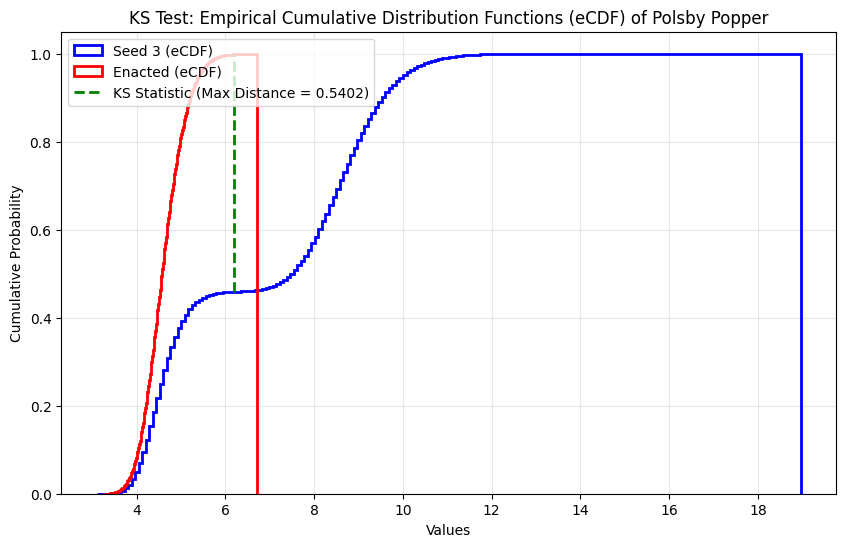

In [128]:
# eg, pb, pp, mms

ks_test_plot(df3['PP'].dropna().to_numpy(),df['PP'].dropna().to_numpy(),"Seed 3","Enacted","Polsby Popper")